# Practical 9 — Data Visualization II

## Objective
Analyze the Titanic dataset using boxplots to understand the distribution of age with respect to each gender and survival status. Provide observations and inferences from the statistics.

## Step 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic dataset Using seaborn built-in dataset
df = sns.load_dataset('titanic')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head(10)

Dataset shape: (891, 15)

First few rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
# Dataset information
print("Dataset Info:")
df.info()
print("\n" + "="*50)
print("\nDataset Description:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Dataset Description:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Check for missing values in relevant columns
print("Missing values in relevant columns:")
print(f"Age: {df['age'].isnull().sum()} missing")
print(f"Sex: {df['sex'].isnull().sum()} missing")
print(f"Survived: {df['survived'].isnull().sum()} missing")

# Check unique values
print("\nUnique values:")
print(f"Gender (sex): {df['sex'].unique()}")
print(f"Survived: {df['survived'].unique()}")
print(f"Survival counts:\n{df['survived'].value_counts()}")

Missing values in relevant columns:
Age: 177 missing
Sex: 0 missing
Survived: 0 missing

Unique values:
Gender (sex): <StringArray>
['male', 'female']
Length: 2, dtype: str
Survived: [0 1]
Survival counts:
survived
0    549
1    342
Name: count, dtype: int64


## Step 2: Boxplot - Age Distribution by Gender

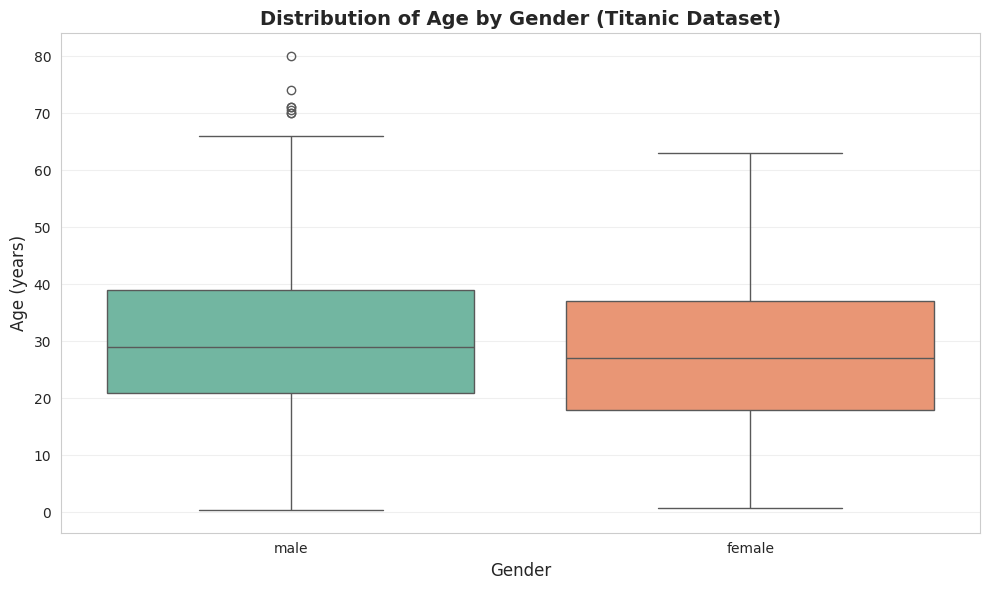

Boxplot Summary - Age by Gender
        count       mean        std   min   25%   50%   75%   max
sex                                                              
female  261.0  27.915709  14.110146  0.75  18.0  27.0  37.0  63.0
male    453.0  30.726645  14.678201  0.42  21.0  29.0  39.0  80.0


In [5]:
# Simple boxplot: Age distribution by Gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='age', data=df, palette='Set2')
plt.title('Distribution of Age by Gender (Titanic Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Boxplot Summary - Age by Gender")
print(df.groupby('sex')['age'].describe())

## Step 3: Boxplot - Age Distribution by Gender and Survival Status

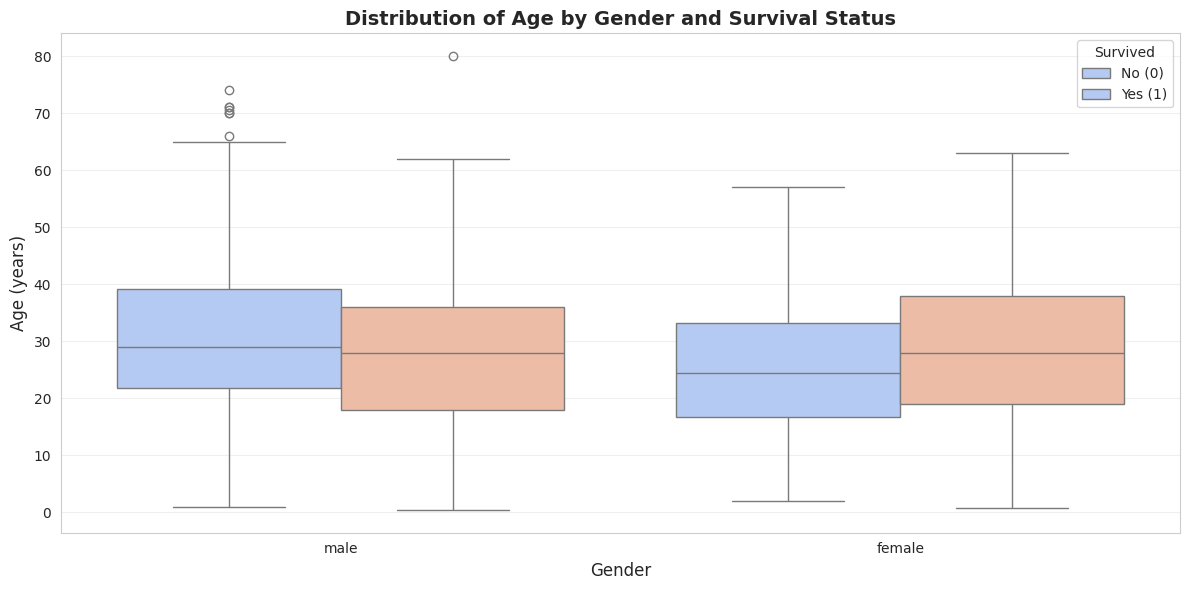

In [6]:
# Boxplot with hue for survival status
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='age', hue='survived', data=df, palette='coolwarm')
plt.title('Distribution of Age by Gender and Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Detailed statistics: Age by Gender and Survival
print("\nAGE STATISTICS BY GENDER AND SURVIVAL STATUS")
print("="*60)
stats = df.groupby(['sex', 'survived'])['age'].describe()
print(stats)

print("\n" + "="*60)
print("MEDIAN AGE BY GENDER AND SURVIVAL")
print("="*60)
median_stats = df.groupby(['sex', 'survived'])['age'].median()
print(median_stats)


AGE STATISTICS BY GENDER AND SURVIVAL STATUS
                 count       mean        std   min    25%   50%    75%   max
sex    survived                                                             
female 0          64.0  25.046875  13.618591  2.00  16.75  24.5  33.25  57.0
       1         197.0  28.847716  14.175073  0.75  19.00  28.0  38.00  63.0
male   0         360.0  31.618056  14.056019  1.00  21.75  29.0  39.25  74.0
       1          93.0  27.276022  16.504803  0.42  18.00  28.0  36.00  80.0

MEDIAN AGE BY GENDER AND SURVIVAL
sex     survived
female  0           24.5
        1           28.0
male    0           29.0
        1           28.0
Name: age, dtype: float64


## Step 4: Additional Visualizations

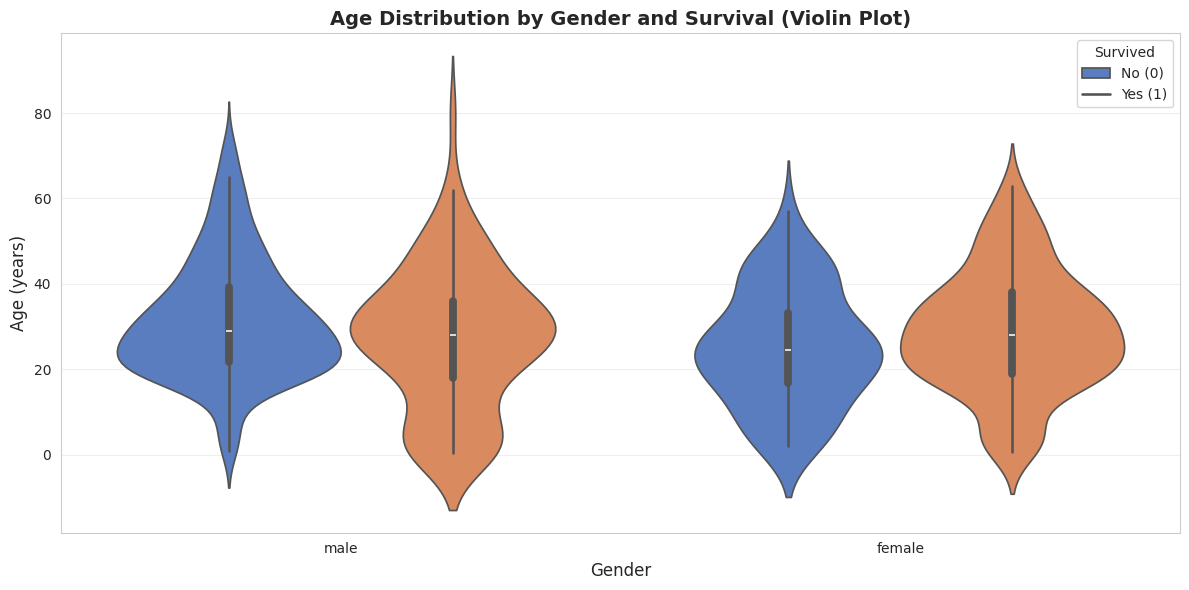

In [8]:
# Violin plot for better visualization
plt.figure(figsize=(12, 6))
sns.violinplot(x='sex', y='age', hue='survived', data=df, palette='muted')
plt.title('Age Distribution by Gender and Survival (Violin Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

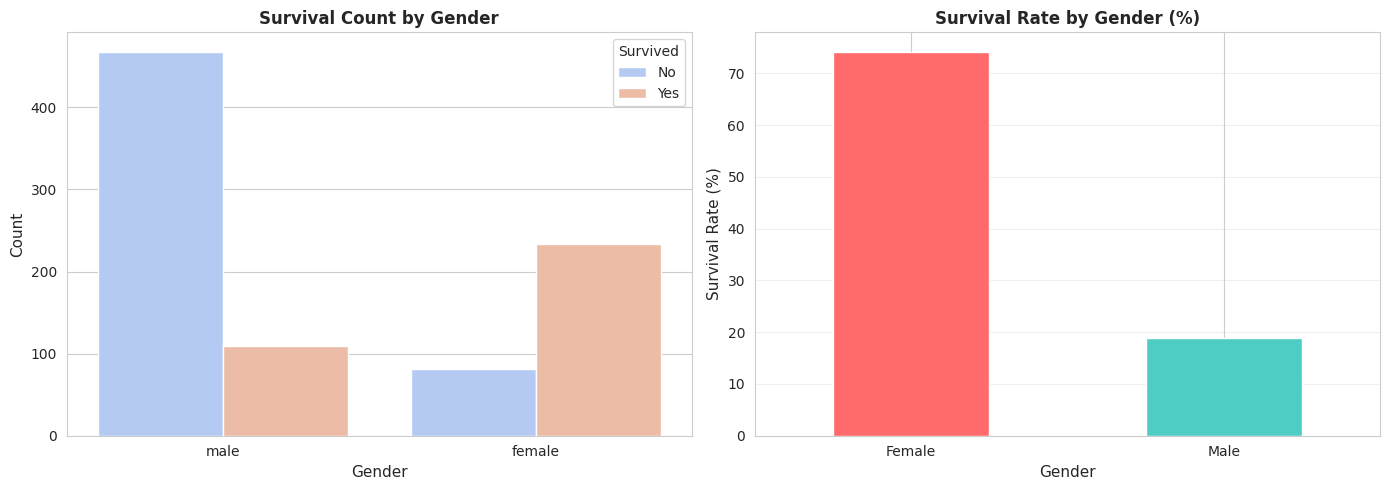

In [9]:
# Count plots and survival rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='sex', hue='survived', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Survival Count by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Survived', labels=['No', 'Yes'])

survival_by_gender = df.groupby('sex')['survived'].apply(lambda x: (x.sum() / len(x)) * 100)
survival_by_gender.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Survival Rate by Gender (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5: Key Observations and Inferences

In [11]:
print("="*70)
print("KEY OBSERVATIONS AND INFERENCES")
print("="*70)

female_data = df[df['sex'] == 'female']
male_data = df[df['sex'] == 'male']

female_survived = female_data[female_data['survived'] == 1]['age']
female_not_survived = female_data[female_data['survived'] == 0]['age']
male_survived = male_data[male_data['survived'] == 1]['age']
male_not_survived = male_data[male_data['survived'] == 0]['age']

print("\n1. GENDER-BASED SURVIVAL:")
female_sr = (female_data['survived'].sum() / len(female_data)) * 100
male_sr = (male_data['survived'].sum() / len(male_data)) * 100
print(f"   Female survival rate: {female_sr:.1f}%")
print(f"   Male survival rate: {male_sr:.1f}%")
print(f"   Observation: Women had significantly higher survival chances (Women and Children First policy)")

print("\n2. AGE DISTRIBUTION BY GENDER:")
print(f"   Female mean age: {female_data['age'].mean():.1f} years, Median: {female_data['age'].median():.1f} years")
print(f"   Male mean age: {male_data['age'].mean():.1f} years, Median: {male_data['age'].median():.1f} years")

print("\n3. AGE IMPACT ON SURVIVAL:")
print("   Females (Survived):")
print(f"      Mean age: {female_survived.mean():.1f}, Median: {female_survived.median():.1f}")
print("   Females (Did not survive):")
print(f"      Mean age: {female_not_survived.mean():.1f}, Median: {female_not_survived.median():.1f}")

print("\n   Males (Survived):")
print(f"      Mean age: {male_survived.mean():.1f}, Median: {male_survived.median():.1f}")
print("   Males (Did not survive):")
print(f"      Mean age: {male_not_survived.mean():.1f}, Median: {male_not_survived.median():.1f}")


KEY OBSERVATIONS AND INFERENCES

1. GENDER-BASED SURVIVAL:
   Female survival rate: 74.2%
   Male survival rate: 18.9%
   Observation: Women had significantly higher survival chances (Women and Children First policy)

2. AGE DISTRIBUTION BY GENDER:
   Female mean age: 27.9 years, Median: 27.0 years
   Male mean age: 30.7 years, Median: 29.0 years

3. AGE IMPACT ON SURVIVAL:
   Females (Survived):
      Mean age: 28.8, Median: 28.0
   Females (Did not survive):
      Mean age: 25.0, Median: 24.5

   Males (Survived):
      Mean age: 27.3, Median: 28.0
   Males (Did not survive):
      Mean age: 31.6, Median: 29.0


## Summary

### Key Findings from Boxplot Analysis:
1. **Strong Gender Effect**: The boxplots clearly show that females had much higher survival rates regardless of age
2. **Age Effect**: For males, there is a clear pattern where younger males had better survival chances
3. **Median Shifts**: Comparing the medians between survived and non-survived groups shows the impact of evacuation decisions
4. **Distribution Differences**: The inter-quartile ranges (IQR) help identify the spread of ages within each group
5. **"Women and Children First" Policy**: Evident in the data - younger passengers and females were prioritized

### Boxplot Elements Explained:
- **Box**: Contains 50% of the data (between 25th and 75th percentile)
- **Line inside box**: Median (50th percentile)
- **Whiskers**: Extend to show data range
- **Outliers**: Individual points show extreme values